<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day5_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd4.5/data/customer_churn/WA_FnUseC_TelcoCustomerChurn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [7]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
print("Contract:")
print(df['Contract'].value_counts())

print("\nInternet Service:")
print(df['InternetService'].value_counts())

print("\nPayment Method:")
print(df['PaymentMethod'].value_counts())

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Internet Service:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Payment Method:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


###Clean the Datase

In [13]:
df = df.drop_duplicates()

In [14]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


###Clean the Datase

In [16]:
print("Duplicate rows : ",df.duplicated().sum())

Duplicate rows :  0


In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Convert totatl charges from object to numeric

In [20]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [21]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [22]:
df=df.dropna()

In [23]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [24]:
df['customerID'].head()

,customerID
0,7590-VHVEG
1,5575-GNVDE
2,3668-QPYBK
3,7795-CFOCW
4,9237-HQITU


In [25]:
df = df.drop('customerID', axis=1)

In [26]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (7032, 20)
Missing values: 0
Duplicates: 22


In [27]:
df = df.drop_duplicates()

In [28]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

Shape: (7010, 20)
Duplicates: 0


###Exploratory Data Analysis (EDA)

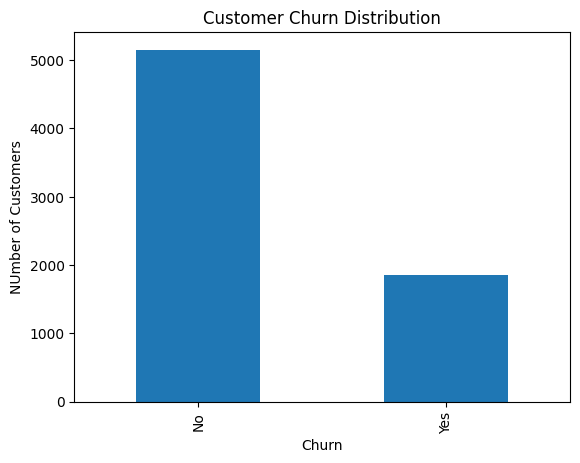

In [31]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('NUmber of Customers')
plt.show()

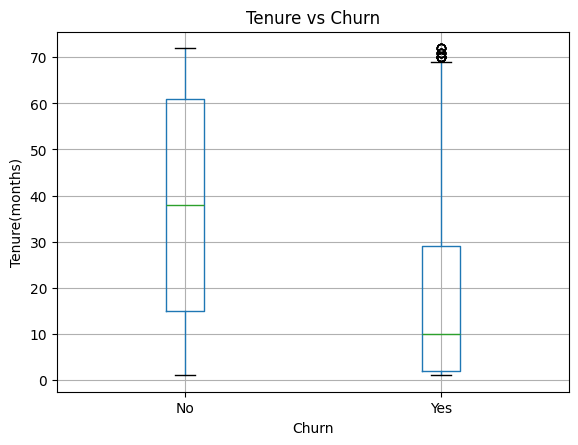

In [33]:
df.boxplot(column='tenure',by='Churn')
plt.title('Tenure vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure(months)')
plt.show()

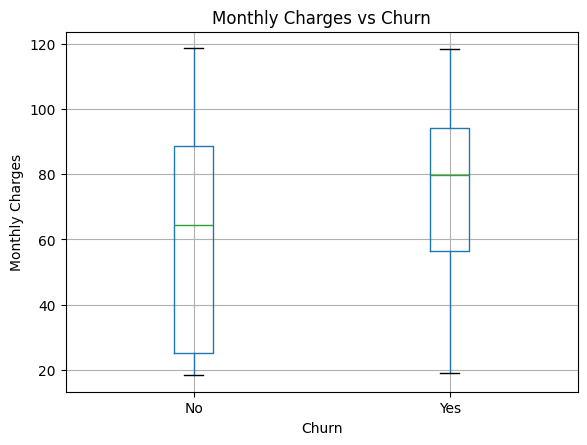

In [34]:
df.boxplot(column='MonthlyCharges', by='Churn')

plt.title('Monthly Charges vs Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

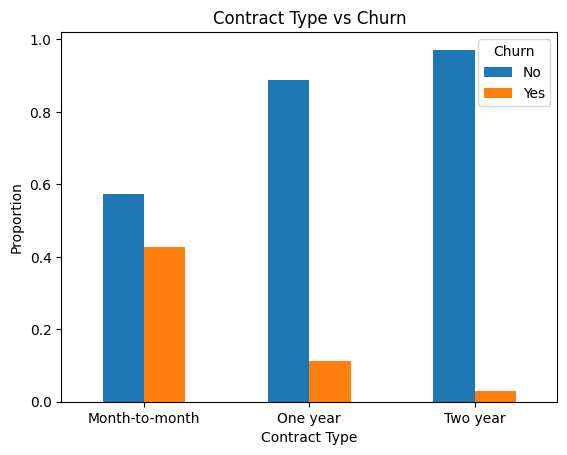

In [35]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
).plot(kind='bar')

plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [37]:
normalize='index'     ### normalize='index' converts each contract category into proportions.

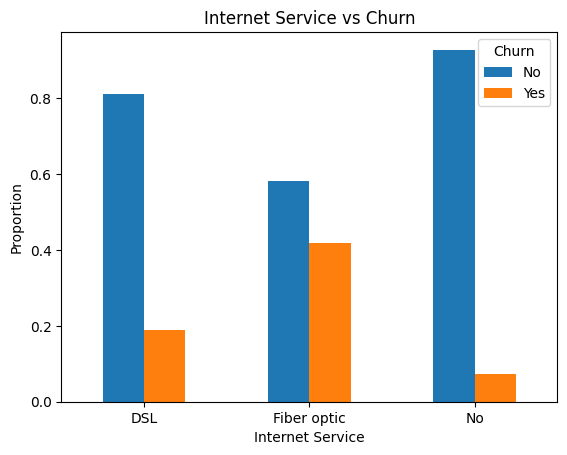

In [38]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
).plot(kind='bar')

plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

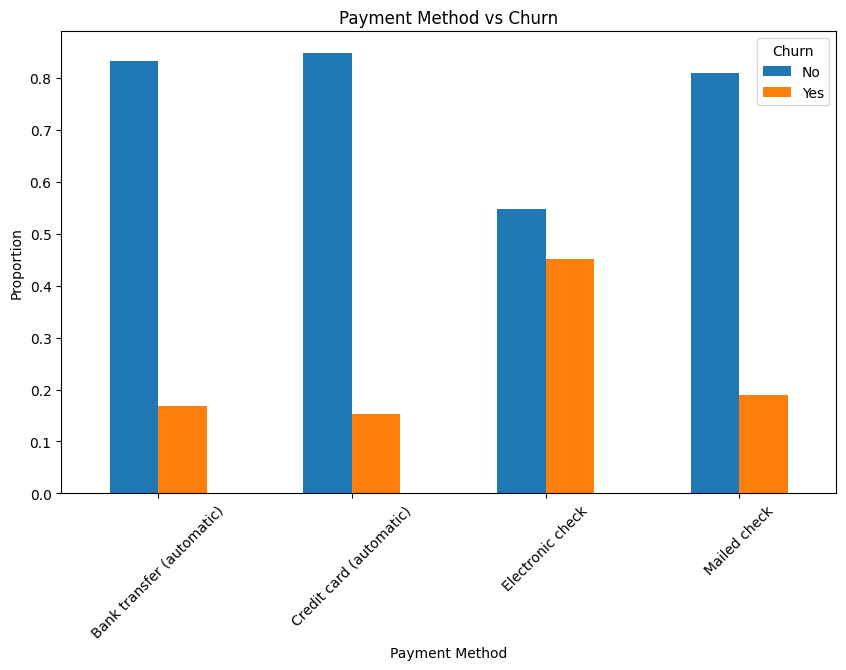

In [39]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
).plot(kind='bar', figsize=(10, 6))

plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.show()

## EDA Observations

1. The target variable is imbalanced, with more customers staying than leaving.
2. Tenure appears to have a relationship with customer churn.
3. Monthly charges show differences between customers who churn and those who stay.
4. Churn rates vary across different contract types.
5. Churn proportions differ across internet service types.
6. Payment methods also show differences in churn behavior.

###Feature Engineering & Encoding

In [40]:
numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object']
).columns

print("Numerical columns:")
print(list(numeric_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [41]:
from sklearn.preprocessing import OneHotEncoder

In [42]:
from sklearn.compose import ColumnTransformer

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ]
)

In [44]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [49]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Re-initialize y to ensure it comes directly from df['Churn'] as a Series of strings
y = df['Churn']

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the 'Churn' column
y_encoded = le.fit_transform(y)

# Convert the encoded array back to a pandas Series, preserving the index and name
y = pd.Series(y_encoded, index=df.index, name='Churn')

print(y.value_counts())

Churn
0    5153
1    1857
Name: count, dtype: int64


In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


###Train/Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Re-calculate numeric and categorical columns based on X_train
# This ensures 'Churn' is not included in the feature lists
numeric_cols_X_train = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_X_train = X_train.select_dtypes(include=['object']).columns

# Redefine the preprocessor with the corrected column lists
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols_X_train),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols_X_train
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

In [54]:
X_test_processed = preprocessor.transform(X_test)